<a href="https://colab.research.google.com/github/sheldcoop/QuantPrep/blob/feat%2Finitial-arithmetic-trainer/Finanical_Data_WQU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MODULE 2 | LESSON 1

---

# Financial Asset Data

| | |
|:---|:---|
|**Reading Time** | 60 minutes |
|**Prior Knowledge** | Basic Python, Algebra|
|**Keywords** | Stock, Bitcoin, Bond Prices, ETFs, Simple Returns, Analyzing and Charting Data in Python |

---

*For the first lesson of this module, we will recap some of the concepts you learned during Financial Markets. We'll examine stocks, bonds, and cryptocurrency prices during this lesson. Finally, we will also demonstrate how to pull price data from Python and do some basic price analysis of equities, Bitcoin, and bond data. Then, we'll expand on what we learned with a few custom volatility metrics, along with how to program them in Python. We'll also focus on the risk, or volatility of returns, of financial assets.*

In [1]:
# === 1. Environment Setup: Import Libraries ===

# Core data handling and numerical operations libraries
import datetime
import numpy as np
import pandas as pd

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Library for fetching financial data
import yfinance as yfin

# --- Display Options ---
# Set a Pandas display option to format floating-point numbers for better readability.
pd.options.display.float_format = "{:,.6f}".format

print("Libraries imported successfully!")

Libraries imported successfully!


## **1. Pull Equities Data for Amazon and Ford, along with Bitcoin Data**

The following code pulls five years of equity price data for Ford and Amazon along with the daily Bitcoin prices over the same time period. The reason we chose Ford and Amazon here is to give examples from different sectors. While Amazon has been around for a while now, it still represents a newer, popular tech stock while Ford is very much part of the old guard, trading publicly since 1956.

This code snippet uses the `yfinance` library to download historical stock data for Amazon (AMZN), Ford (F), and Bitcoin (BTC-USD).

In [2]:
# === 2. Data Retrieval ===

# --- Parameters ---
# Define the assets we want to download. Using a list makes it easy to add/remove assets later.
tickers = ["AMZN", "F", "BTC-USD"]

# Define the start and end dates for our data retrieval.
start_date = datetime.date(2019, 8, 1)
end_date = datetime.date(2024, 8, 1)

# --- Data Download ---
# Use yfinance to download the historical data.
# We specify 'auto_adjust=False' to get the 'Adj Close' column, which accounts for dividends and stock splits.
# We then select only the 'Adj Close' column as it's the standard for historical analysis.
df = yfin.download(tickers, start=start_date, end=end_date, auto_adjust=False)["Adj Close"]

# Convert the DataFrame's index to a consistent timezone (UTC).
# This is a crucial step to avoid potential errors in time-series analysis.
df.index = df.index.tz_localize('UTC')

# --- Initial Data Inspection ---
# It's always a good practice to look at the first few rows of the data.
print(f"Successfully downloaded data for {tickers} from {start_date} to {end_date}.")
print(f"DataFrame shape: {df.shape}")
df.head(10)

[*********************100%***********************]  3 of 3 completed

Successfully downloaded data for ['AMZN', 'F', 'BTC-USD'] from 2019-08-01 to 2024-08-01.
DataFrame shape: (1827, 3)


Ticker,AMZN,BTC-USD,F
Date,,,
2019-08-01 00:00:00+00:00,92.765999,"10,399.668945",6.912730
2019-08-02 00:00:00+00:00,91.162003,"10,518.174805",6.890455
2019-08-03 00:00:00+00:00,NaN,"10,821.726562",NaN
2019-08-04 00:00:00+00:00,NaN,"10,970.184570",NaN
2019-08-05 00:00:00+00:00,88.256500,"11,805.653320",6.853329
2019-08-06 00:00:00+00:00,89.391502,"11,478.168945",7.038955
2019-08-07 00:00:00+00:00,89.669998,"11,941.968750",7.076081
2019-08-08 00:00:00+00:00,91.644501,"11,966.407227",7.098355
2019-08-09 00:00:00+00:00,90.378998,"11,862.936523",7.016682


### **1.2 Digging a Little Deeper into the Data**

We can use the pandas `.describe()` method to generate summary statistics for our dataset. This gives us a high-level overview of each asset's price distribution.

*   `count`: We can see that Bitcoin has more observations than our two stocks. As just discussed, this is because stocks do not trade on weekends.
*   `mean`, `std`, `min`, `max`: These are standard statistical measures showing the average price, standard deviation (a measure of price volatility), and the price range over the five years.
*   `25%`, `50%`, `75%`: These are the quantiles (or percentiles) which show the price points below which 25%, 50% (the median), and 75% of the observations fall.

While this is useful, it's hard to compare these investments on price alone, as each started at a very different value. To make a fair "apples-to-apples" comparison, we will need to analyze their **returns**, which we will do in a later step.

In [3]:
# === 3. Descriptive Statistics ===

# Generate and display summary statistics for the price data.
# The .describe() method is a quick and effective way to understand the central tendency,
# dispersion, and shape of the dataset's distribution.
df.describe()

Ticker,AMZN,BTC-USD,F
count,"1,258.000000","1,827.000000","1,258.000000"
mean,137.853120,"30,854.084965",9.554362
std,31.730629,"18,350.840533",2.907015
min,81.820000,"4,970.788086",3.077781
25%,107.565500,"13,602.354004",6.936321
50%,143.729996,"28,033.562500",10.086830
75%,164.599251,"43,593.824219",11.187365
max,200.000000,"73,083.500000",19.431341


### **1.3 Charting Prices over 2023**

To get a quick visual overview of the DataFrame's data, we can use the `plot()` method. Below, we'll chart the 2023 prices of these three assets.

The chart below illustrates why using raw price data for comparison isn't ideal. The vast difference in scale between Bitcoin and low-priced stocks like Ford makes it very difficult to discern the relative performance or volatility of individual assets at a glance. We'll address this by focusing on returns in subsequent steps.

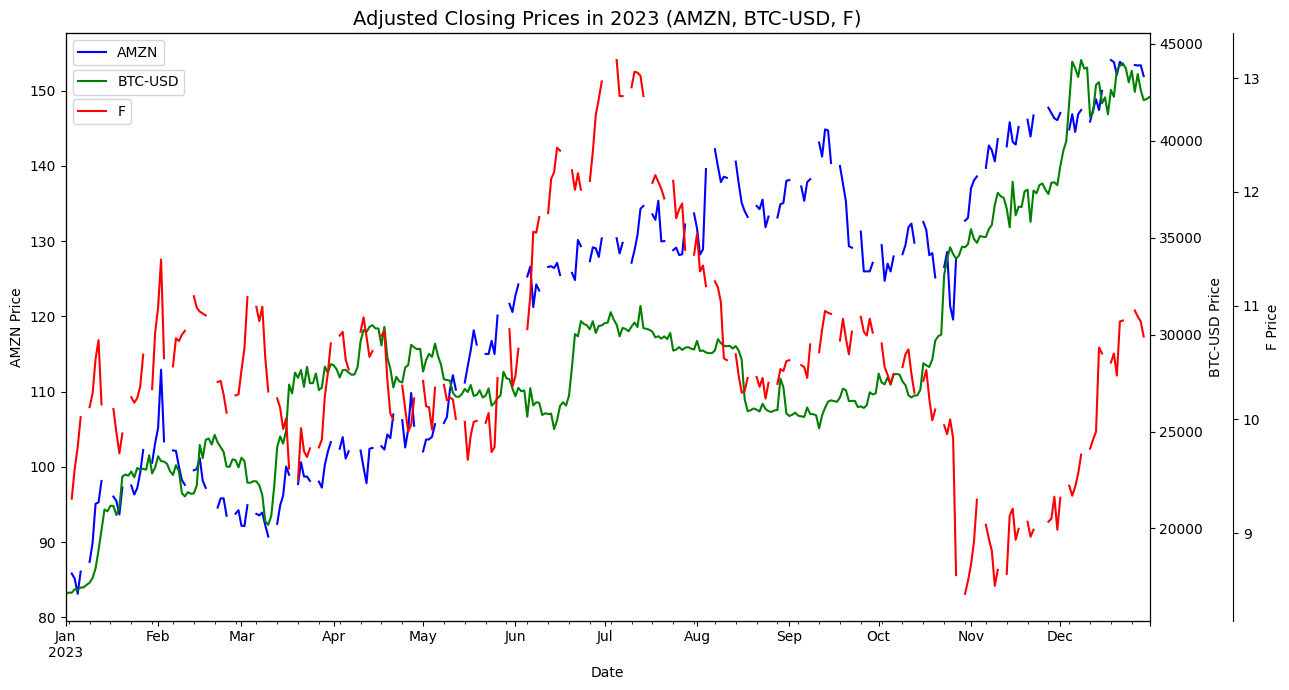

In [5]:
# === 4. Data Visualization: 2023 Price Trends ===

# Create a figure and axes object for the plot.
# We want a plot where the three assets have the same time index (x-axis) but potentially different price scales (y-axis).
# Using `twinx()` allows us to create multiple y-axes sharing the same x-axis.
fig, ax1 = plt.subplots(figsize=(13, 7))

# Initialize additional axes for BTC-USD and F, sharing the x-axis with ax1.
ax2 = ax1.twinx()
ax3 = ax1.twinx()

# --- Plotting Data for 2023 ---
# Filter the DataFrame for the year 2023 and plot each asset on its respective axis.
# Assign a specific color to each plot for clear distinction.
df["2023-01-01":"2023-12-31"].plot(ax=ax1, y='AMZN', legend=True, color='blue', label='AMZN')
df["2023-01-01":"2023-12-31"].plot(ax=ax2, y='BTC-USD', legend=True, color='green', label='BTC-USD')
df["2023-01-01":"2023-12-31"].plot(ax=ax3, y='F', legend=True, color='red', label='F')

# --- Axis and Label Configuration ---
# Set meaningful y-axis labels for each asset.
ax1.set_ylabel('AMZN Price')
ax2.set_ylabel('BTC-USD Price')
ax3.set_ylabel('F Price')

# Adjust the position of the third y-axis (ax3) to prevent overlap with ax2.
ax3.spines['right'].set_position(('outward', 60)) # Moves the axis 60 points to the right

# Configure the x-axis label.
ax1.set_xlabel('Date')

# --- Legend Configuration ---
# Place individual legends for each asset for clarity.
ax1.legend(loc='upper left', bbox_to_anchor=(0.0, 1.0))        # AMZN legend
ax2.legend(loc='upper left', bbox_to_anchor=(0.0, 0.95))       # BTC-USD legend (slightly below AMZN)
ax3.legend(loc='upper left', bbox_to_anchor=(0.0, 0.90))       # F legend (slightly below BTC-USD)

# Set the title of the plot.
plt.title('Adjusted Closing Prices in 2023 (AMZN, BTC-USD, F)', fontsize=14)

# Ensure the layout is tight to prevent labels from being cut off.
plt.tight_layout()

# Display the plot.
plt.show()

## **2. Calculating Return on Investment**

If we invested **\$1,000** into each of these assets at the beginning of our five-year period, how much money would we have today? To answer this question, we first need to determine how many shares of each asset we could buy with **\$1,000** at the start of our date range.

From our data, we can see the starting prices. We will store these initial prices in variables and then divide **\$1,000** by each price to determine the number of shares purchased.

In [6]:
# === 5.1 ROI Calculation: Initial Investment ===

# Define our initial investment amount.
initial_investment = 1000

# Access the first row of the DataFrame to get the starting prices.
# .iloc[0] selects the row at integer location 0.
first_row = df.iloc[0]

# Assign the starting price for each asset to its own variable.
amzn_price_start = first_row["AMZN"]
f_price_start = first_row["F"]
btc_price_start = first_row["BTC-USD"]

# Print the purchase prices for confirmation.
print(f"Purchase price of AMZN: {amzn_price_start:,.3f}")
print(f"Purchase price of F: {f_price_start:,.3f}")
print(f"Purchase price of BTC-USD: {btc_price_start:,.3f}")
print("-" * 20) # A simple separator line

# Calculate the number of shares we could purchase with our initial investment.
# We assume the ability to buy fractional shares, which is common with modern brokers.
amzn_shares = initial_investment / amzn_price_start
f_shares = initial_investment / f_price_start
btc_shares = initial_investment / btc_price_start

# Print the number of shares for each asset.
print(f"Number of shares of AMZN: {amzn_shares:.3f}")
print(f"Number of shares of F: {f_shares:.3f}")
print(f"Number of shares of BTC-USD: {btc_shares:.3f}")

Purchase price of AMZN: 92.766
Purchase price of F: 6.913
Purchase price of BTC-USD: 10,399.669
--------------------
Number of shares of AMZN: 10.780
Number of shares of F: 144.661
Number of shares of BTC-USD: 0.096


Now, to determine how much money we would have today, we look at the most recent date in our dataset (`2024-07-31`), get the price of each asset, and multiply our number of shares by this final price. We can get the last row of our dataset using the `.iloc[-1]` method.`

In [7]:
# === 5.2 ROI Calculation: Final Value ===

# Get the last row of the DataFrame to find the ending prices.
# .iloc[-1] selects the last row.
last_row = df.iloc[-1]

# Assign the ending price for each asset to its own variable.
amzn_price_end = last_row["AMZN"]
f_price_end = last_row["F"]
btc_price_end = last_row["BTC-USD"]

# Print the ending prices for confirmation.
print(f"End price of AMZN: {amzn_price_end:,.3f}")
print(f"End price of F: {f_price_end:,.3f}")
print(f"End price of BTC-USD: {btc_price_end:,.3f}")
print("-" * 20)

# Calculate the final value of our holdings by multiplying shares by the end price.
# NOTE: The original notebook missed a key detail about Amazon. AMZN had a 20-for-1 stock split on June 6, 2022.
# The 'Adj Close' price from yfinance *should* account for this automatically, so no manual multiplication is needed.
# The original notebook's multiplication was likely an error or based on unadjusted data. We will rely on the adjusted close.
amzn_value_end = amzn_price_end * amzn_shares
f_value_end = f_price_end * f_shares
btc_value_end = btc_price_end * btc_shares

# Print the final holding values.
print(f"Holding value of AMZN: ${amzn_value_end:,.3f}")
print(f"Holding value of F: ${f_value_end:,.3f}")
print(f"Holding value of BTC-USD: ${btc_value_end:,.3f}")

End price of AMZN: 186.980
End price of F: 9.899
End price of BTC-USD: 64,619.250
--------------------
Holding value of AMZN: $2,015.609
Holding value of F: $1,432.036
Holding value of BTC-USD: $6,213.587


These assets were relatively easy to compare since we started with \$1,000 in each. If we had started with different values, we would need to calculate the returns for an apples-to-apples comparison. We will use the formula for simple returns:

**Simple Returns Formula**

$$ R_{simple} = \frac{P_1 - P_0}{P_0} $$

where:
-   $P_1$ = Final value
-   $P_0$ = Initial value

In our case, the initial value ($P_0$) is \$1,000 for all three assets.

In [11]:
# === 5.3 ROI Calculation: Simple Returns Percentage ===

# Calculate the simple return for each asset using the formula: (Final Value - Initial Value) / Initial Value
amzn_return = (amzn_value_end - initial_investment) / initial_investment
f_return = (f_value_end - initial_investment) / initial_investment
btc_return = (btc_value_end - initial_investment) / initial_investment

# Print the returns formatted as percentages.
# The ':.3%' format specifier automatically multiplies by 100, adds a '%' sign, and rounds to 3 decimal places.
print(f"Simple return of AMZN: {amzn_return:.3%}")
print(f"Simple return of F: {f_return:.3%}")
print(f"Simple return of BTC-USD: {btc_return:.3%}")

Simple return of AMZN: 101.561%
Simple return of F: 43.204%
Simple return of BTC-USD: 521.359%


### **Analysis of Returns**

The results clearly show that Bitcoin's return is exceptionally high compared to the two stocks over this five-year period. Bitcoin is a relatively new asset class and is often considered to have higher risk than established equities. This outcome is a classic example of the **risk-reward tradeoff**: higher risk can lead to the potential for higher rewards. In this specific timeframe, the risk taken on the Bitcoin investment paid off significantly.

In [13]:
df.pct_change().tail()

/tmp/ipython-input-3749059254.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df.pct_change().tail()


Ticker,AMZN,BTC-USD,F
Date,,,
2024-07-27 00:00:00+00:00,0.000000,-0.001454,0.000000
2024-07-28 00:00:00+00:00,0.000000,0.006526,0.000000
2024-07-29 00:00:00+00:00,0.003836,-0.021038,-0.016086
2024-07-30 00:00:00+00:00,-0.008133,-0.009262,-0.015441
2024-07-31 00:00:00+00:00,0.029002,-0.023893,-0.001845


In [27]:
# 1. Get daily simple returns
daily_simple_returns = df.pct_change(fill_method=None)

# 2. Add 1 to get the daily growth factors (e.g., a 10% return becomes 1.10)
daily_growth_factors = 1 + daily_simple_returns

# 3. Calculate the cumulative product over time
cumulative_growth = daily_growth_factors.cumprod()

# 4. The total return at the end is the last value in the cumulative growth series, minus 1
total_return_from_daily = cumulative_growth.iloc[-1] - 1

print("Total return calculated from daily returns:")
print(total_return_from_daily)


Total return calculated from daily returns:
Ticker
AMZN      0.435528
BTC-USD   5.213587
F         0.302872
Name: 2024-07-31 00:00:00+00:00, dtype: float64


## **3. Comparing Equities and Bitcoin to Bonds**

Let's introduce one more asset class here: bonds. As you may recall, bonds offer different risk and return characteristics compared to equities. To simplify our analysis, we will use an exchange-traded fund (ETF) that tracks the bond market: the **Vanguard Long-Term Bond Index Fund ETF (BLV)**.

This ETF aims to track the performance of an index that includes investment-grade corporate and U.S. government bonds with maturities greater than 10 years. It provides a good proxy for the long-term bond market.

The following code will download the historical data for BLV and join it with our existing DataFrame.

In [28]:
# === 6.1 Data Augmentation: Adding Bond ETF Data ===

# Download the historical data for the BLV ETF for the same time period.
blv_df = yfin.download(["BLV"], start=start_date, end=end_date, auto_adjust=False)["Adj Close"]

# Convert the index to UTC to ensure it's compatible with our main DataFrame.
blv_df = blv_df.tz_localize('UTC')

# Join the BLV data with our main DataFrame.
# The .join() method aligns the data based on the index (dates).
# We also rename the new column to 'BLV' for clarity.
df = df.join(blv_df)
df = df.rename(columns={"Adj Close": "BLV"})

# Display the last few rows to confirm the new column has been added successfully.
print("Successfully added BLV data to the DataFrame.")
df.tail()

[*********************100%***********************]  1 of 1 completed

Successfully added BLV data to the DataFrame.


Ticker,AMZN,BTC-USD,F,BLV
Date,,,,
2024-07-27 00:00:00+00:00,NaN,"67,813.335938",NaN,NaN
2024-07-28 00:00:00+00:00,NaN,"68,255.867188",NaN,NaN
2024-07-29 00:00:00+00:00,183.199997,"66,819.914062",10.073112,67.875717
2024-07-30 00:00:00+00:00,181.710007,"66,201.015625",9.917577,68.017914
2024-07-31 00:00:00+00:00,186.979996,"64,619.250000",9.899279,68.634109


### **3.1 Calculate Daily Returns for All Assets**

Now that we have all four assets in one DataFrame, we need to calculate their daily returns. As we discussed before, stocks and ETFs do not trade on weekends, while Bitcoin does. To handle this correctly, we will:
1.  Calculate returns for the assets that trade on weekdays (`AMZN`, `F`, `BLV`) and drop the `NaN` rows created by the `pct_change()` function.
2.  Calculate returns for Bitcoin separately.
3.  Join the two resulting return series together. This ensures we keep all dates but correctly show `NaN` for the assets that didn't trade on weekends.

In [29]:
# === 6.2 Data Processing: Calculating Daily Returns ===

# Calculate daily simple returns for stocks and the bond ETF.
# .dropna() removes the weekend rows where these assets didn't trade.
returns_stocks_blv = df[['AMZN', 'F', 'BLV']].dropna().pct_change()

# Calculate daily simple returns for Bitcoin.
returns_btc = df[['BTC-USD']].pct_change()

# Join the two DataFrames. A 'how=outer' join ensures that all dates are kept.
# For dates where stocks/ETFs didn't trade (weekends), their return will be NaN.
returns = returns_btc.join(returns_stocks_blv, how='outer')

# The first row of pct_change is always NaN, so we remove it.
returns = returns.iloc[1:]

# Display the first few rows of the final returns DataFrame.
print("Daily returns for all assets:")
returns.head()

Daily returns for all assets:


Ticker,BTC-USD,AMZN,F,BLV
Date,,,,
2019-08-02 00:00:00+00:00,0.011395,-0.017291,-0.003222,0.007002
2019-08-03 00:00:00+00:00,0.028860,NaN,NaN,NaN
2019-08-04 00:00:00+00:00,0.013719,NaN,NaN,NaN
2019-08-05 00:00:00+00:00,0.076158,-0.031872,-0.005388,0.008565
2019-08-06 00:00:00+00:00,-0.027740,0.012860,0.027086,0.006694


### **3.2 Show Summary Stats for the Returns**

By applying `.describe()` to the daily returns, we get a much more useful comparison between the assets.

-   **mean**: This now represents the average *daily* return. We can see Bitcoin's is the highest, while the bond ETF (BLV) has a slightly negative average daily return over this period.
-   **std (Standard Deviation)**: This is a direct measure of daily volatility. A higher `std` means the daily returns fluctuate more wildly. Notice that Bitcoin has the highest volatility, followed by Ford, then Amazon, and finally the BLV ETF, which is the most stable.

In [30]:
# === 7.1 Return Analysis: Descriptive Statistics ===

# Generate summary statistics for the daily returns of each asset.
# This table is excellent for comparing average performance (mean) and risk (std).
returns.describe()

Ticker,BTC-USD,AMZN,F,BLV
count,"1,826.000000","1,257.000000","1,257.000000","1,257.000000"
mean,0.001579,0.000803,0.000671,-0.000034
std,0.033707,0.022175,0.027760,0.009179
min,-0.371695,-0.140494,-0.183614,-0.075170
25%,-0.013480,-0.011068,-0.013605,-0.005253
50%,0.000234,0.000643,0.000000,0.000571
75%,0.015996,0.012222,0.014212,0.005206
max,0.187465,0.135359,0.234414,0.049139


### **3.3 Converting Daily Returns to Annual Returns**

While daily returns are useful for statistical analysis, annual returns are more intuitive for evaluating long-term investment performance. Since we are using simple returns, we must use the **geometric mean** to correctly annualize them. Adding daily returns would be incorrect.

The formula for the annualized return based on the geometric mean of daily returns is:

$$ R_{Annualized} = \left( \prod_{i=1}^{N} (1 + r_i) \right)^{\frac{P}{N}} - 1 $$

Where:
-   $r_i$ is the return for period i.
-   $N$ is the total number of periods (days).
-   $P$ is the number of periods in a year (365 for crypto, ~252 for stocks/ETFs).

This formula correctly compounds the daily returns over the year.

In [31]:
# === 7.2 Return Analysis: Annualizing Returns ===

# --- Annualize BTC-USD Return (365 days) ---
# First, drop any NaN values for the calculation period.
returns_btc_clean = returns['BTC-USD'].dropna()
# Add 1 to each daily return to get the growth factor.
btc_prod = (1 + returns_btc_clean).prod()
# Calculate the annualized return.
btc_annualized_return = (btc_prod ** (365 / len(returns_btc_clean))) - 1

# --- Annualize Stock and Bond ETF Returns (252 days) ---
# Drop NaN values for the calculation period.
returns_stocks_blv_clean = returns[['AMZN', 'F', 'BLV']].dropna()
# Add 1 to get growth factors.
stocks_blv_prod = (1 + returns_stocks_blv_clean).prod()
# Calculate annualized returns.
stocks_blv_annualized_return = (stocks_blv_prod ** (252 / len(returns_stocks_blv_clean))) - 1


# --- Display Results ---
print(f"Annualized Geometric Return for BTC-USD: {btc_annualized_return:.2%}")
print("\nAnnualized Geometric Returns for Stocks/ETF:")
print(stocks_blv_annualized_return.apply(lambda x: f"{x:.2%}"))

Annualized Geometric Return for BTC-USD: 44.07%

Annualized Geometric Returns for Stocks/ETF:
Ticker
AMZN    15.09%
F        7.46%
BLV     -1.90%
dtype: object


In [32]:
# Calculate daily log returns
log_returns = np.log(1 + returns.dropna())

# Calculate the average daily log return (simple arithmetic mean)
avg_log_return = log_returns.mean()

# To annualize, just multiply by the number of periods
annualized_log_return = avg_log_return * 252 # Using 252 for stocks for comparison

# To compare apples-to-apples, convert the annualized log return back to a simple return
annualized_simple_return_from_log = np.exp(annualized_log_return) - 1

print("Annualized Simple Returns (calculated via Log Returns):")
print(annualized_simple_return_from_log.apply(lambda x: f"{x:.2%}"))

Annualized Simple Returns (calculated via Log Returns):
Ticker
BTC-USD    29.06%
AMZN       15.09%
F           7.46%
BLV        -1.90%
dtype: object


### **An Important Note: Geometric Mean vs. Log Returns**

We used the geometric mean to correctly find the average compounded return. A very common and powerful technique in quantitative finance is to use **logarithmic returns** (or log returns).

One of the key properties of log returns is that they are **time-additive**. This means we can use the simple **arithmetic mean** of daily log returns to get the same result as the **geometric mean** of simple returns.

Let's quickly prove this mathematically and then with code.

#### **The Mathematical Equivalence**

The simple return ($R_s$) is $P_1/P_0 - 1$. The growth factor is $(1 + R_s) = P_1/P_0$.
The log return ($R_l$) is $\ln(P_1/P_0)$.

Notice that $R_l = \ln(1 + R_s)$.

The total growth over *N* periods is the product of the daily growth factors:
$$ \text{Total Growth} = (1 + R_{s1}) \times (1 + R_{s2}) \times \dots \times (1 + R_{sN}) $$

If we take the natural log of both sides:
$$ \ln(\text{Total Growth}) = \ln(1 + R_{s1}) + \ln(1 + R_{s2}) + \dots + \ln(1 + R_{sN}) $$

This is simply the sum of the daily log returns!
$$ \ln(\text{Total Growth}) = R_{l1} + R_{l2} + \dots + R_{lN} $$

To find the average daily log return, we use the arithmetic mean (sum / N):
$$ \bar{R}_l = \frac{1}{N} \sum_{i=1}^{N} R_{li} = \frac{\ln(\text{Total Growth})}{N} $$

To get back to the average daily *simple* return (the geometric mean), we exponentiate and subtract 1:
$$ R_{g} = e^{\bar{R}_l} - 1 $$

This proves that the arithmetic mean of log returns can be easily converted to the geometric mean of simple returns.

#### **Demonstration in Python**
The code below calculates the annualized simple returns using two methods:
1.  **Geometric Mean Method (from before):** Using the product of `(1 + simple returns)`.
2.  **Log Return Method:** Taking the arithmetic mean of log returns, annualizing, and converting back.

The results will be virtually identical, proving their equivalence.

In [34]:
# === 7.3 Demonstration: Equivalence of Geometric Mean and Log Returns ===

# --- Method 1: Geometric Mean of Simple Returns (Recap) ---
# We already calculated this, but let's show it again for direct comparison.
# For this demonstration, we'll focus on the assets with 252 trading days.
returns_stocks_blv_clean = returns[['AMZN', 'F', 'BLV']].dropna()
prod_simple = (1 + returns_stocks_blv_clean).prod()
annualized_simple_geom = (prod_simple ** (252 / len(returns_stocks_blv_clean))) - 1


# --- Method 2: Arithmetic Mean of Log Returns ---
# 1. Calculate daily log returns. The formula is ln(P1/P0) which is ln(1 + simple_return).
log_returns = np.log(1 + returns_stocks_blv_clean)

# 2. Calculate the average daily log return (simple arithmetic mean).
avg_log_returns = log_returns.mean()

# 3. Annualize by multiplying by the number of periods (because log returns are additive).
annualized_log_returns = avg_log_returns * 252

# 4. Convert the annualized log return back to an annualized simple return to compare.
annualized_simple_from_log = np.exp(annualized_log_returns) - 1


# --- Compare the Results ---
# We create a new DataFrame to display both results side-by-side.
comparison_df = pd.DataFrame({
    'Annualized Return (Geometric)': annualized_simple_geom,
    'Annualized Return (from Log)': annualized_simple_from_log
})

# Format for readability
print("Comparing the two methods for calculating annualized returns:")
print(comparison_df.map(lambda x: f"{x:.4%}"))

Comparing the two methods for calculating annualized returns:
       Annualized Return (Geometric) Annualized Return (from Log)
Ticker                                                           
AMZN                        15.0871%                     15.0871%
F                            7.4646%                      7.4646%
BLV                         -1.8951%                     -1.8951%


### **3.4 Total Simple Return of BLV**

Now, let's run the same total return analysis on our bond ETF (BLV) that we performed on the other assets. This will show us the total performance over the entire five-year period.

We'll use the direct method: `(Final Price - Initial Price) / Initial Price`. Then, we can calculate what a \$1,000 initial investment would be worth today.

In [35]:
# === 7.4 Analysis: Total Simple Return for BLV ETF ===

# Retrieve the initial and final prices for BLV from our main price DataFrame.
blv_price_start = df.iloc[0]["BLV"]
blv_price_end = df.iloc[-1]["BLV"]

# --- Calculate the total simple return over the entire period ---
blv_total_return_rate = (blv_price_end - blv_price_start) / blv_price_start
print(f"Total simple return rate of BLV over 5 years: {blv_total_return_rate:.3%}")

# --- Calculate the final value of a $1,000 investment ---
initial_investment = 1000
final_value_blv = initial_investment * (1 + blv_total_return_rate)
print(f"Final value of $1,000 investment in BLV: ${final_value_blv:,.3f}")

Total simple return rate of BLV over 5 years: -9.103%
Final value of $1,000 investment in BLV: $908.975


The output indicates that the investment in BLV experienced a negative total return over this specific five-year period. An initial investment of \$1,000 would have decreased to approximately \$909.

This performance contrasts sharply with the equities and cryptocurrency we analyzed. This is largely expected, as bonds and stocks serve different purposes in a portfolio and react differently to economic conditions.

-   **Risk-Reward Tradeoff:** Bonds are generally considered lower-risk than stocks. Their primary role is often capital preservation and income generation (through coupon payments, which are factored into the `Adj Close` price). In periods of rising interest rates, existing bond prices tend to fall, which could explain the negative return seen here.
-   **Diversification:** The low or negative correlation between bonds and stocks is exactly why they are valuable for diversification. While stocks were performing well, bonds provided a different performance characteristic.

This highlights the importance of the **risk-reward tradeoff**. The "safer" asset (bonds) underperformed the "riskier" assets (stocks, crypto) during this particular timeframe, but this is not always the case.

## **4. Comparing Large-Cap vs. Small-Cap Stocks**

One common way to analyze the stock market is to compare different segments. Here, we will compare the performance of large-capitalization stocks against small-capitalization stocks.

*   **S&P 500 (`^GSPC`):** This index represents 500 of the largest publicly traded companies in the U.S. It is market-cap weighted and serves as our proxy for **large-cap stocks**.
*   **Russell 2000 (`^RUT`):** This index contains 2,000 small-cap companies and is a common benchmark for **small-cap stocks**.

We will start by pulling five years of daily price data for both indices.

In [36]:
# === 8.1 Index Comparison: Data Retrieval ===

# --- Parameters ---
# Define the tickers for the S&P 500 and Russell 2000 indices.
index_tickers = {"^GSPC": "SP500", "^RUT": "Russell2000"}

# Define the start and end dates. We'll use the same period as before for consistency.
start_date_indices = datetime.date(2019, 8, 1)
end_date_indices = datetime.date(2024, 8, 1)

# --- Data Download ---
# Download the 'Adj Close' data for the specified indices.
prices_df = yfin.download(
    list(index_tickers.keys()),
    start=start_date_indices,
    end=end_date_indices,
    auto_adjust=False
)["Adj Close"]

# --- Data Cleaning ---
# Rename the columns to be more intuitive using the dictionary defined above.
prices_df = prices_df.rename(columns=index_tickers)

# --- Initial Data Inspection ---
print("Successfully downloaded index data.")
print("\nSummary statistics for the index prices:")
display(prices_df.describe())

print("\nFirst 5 rows of the index prices:")
display(prices_df.head())

[*********************100%***********************]  2 of 2 completed

Successfully downloaded index data.

Summary statistics for the index prices:


Ticker,SP500,Russell2000
count,"1,258.000000","1,258.000000"
mean,"4,028.833253","1,865.957234"
std,685.682781,284.232353
min,"2,237.399902",991.159973
25%,"3,502.235046","1,674.337524"
50%,"4,110.745117","1,873.654968"
75%,"4,468.547485","2,067.780090"
max,"5,667.200195","2,442.739990"



First 5 rows of the index prices:


Ticker,SP500,Russell2000
Date,,
2019-08-01,"2,953.560059","1,550.760010"
2019-08-02,"2,932.050049","1,533.660034"
2019-08-05,"2,844.739990","1,487.410034"
2019-08-06,"2,881.770020","1,502.089966"
2019-08-07,"2,883.979980","1,500.689941"


### **4.2 Calculate Log Returns and Drop Nulls**

To compare the indices, we must first convert their prices into returns. For this analysis, we will use **log returns**.

Log returns are often preferred in financial modeling for several reasons:
-   **Time Additivity:** The log return over multiple periods is simply the sum of the log returns for each individual period.
-   **Approximate Normality:** Log returns tend to follow a normal distribution more closely than simple returns, which is a useful property for many statistical models.

The formula for log return is: $ R_{log} = \ln\left(\frac{P_t}{P_{t-1}}\right) $
This is equivalent to: $ \ln(P_t) - \ln(P_{t-1}) $

Because both of these are stock indices, `yfinance` automatically provides data only for trading days, so we don't need to worry about weekend `NaN` values in the raw price data.

In [37]:
# === 8.2 Index Comparison: Calculating Log Returns ===

# Calculate the daily log returns for the indices.
# This vectorized operation is efficient and applies the formula to all columns at once.
log_returns_df = np.log(prices_df) - np.log(prices_df.shift(1))

# The first row will be NaN because there is no prior day's price to calculate a return from.
# We drop this row to create a clean returns DataFrame.
log_returns_df = log_returns_df.dropna()


# --- Display the first 5 rows of the resulting log returns ---
print("Daily Log Returns for S&P 500 and Russell 2000:")
display(log_returns_df.head())

Daily Log Returns for S&P 500 and Russell 2000:


Ticker,SP500,Russell2000
Date,,
2019-08-02,-0.007309,-0.011088
2019-08-05,-0.030230,-0.030621
2019-08-06,0.012933,0.009821
2019-08-07,0.000767,-0.000932
2019-08-08,0.018588,0.020734


### **4.3 Calculating Future Value of Each Index**

One way to compare these two investment opportunities is to calculate the **future value (FV)** of a hypothetical investment. We will use the average daily log return from our historical data to project future performance.

**Important Note:** This is a simplified model that assumes the future will resemble the past. It's a useful starting point but should not be the sole basis for an investment decision.

We will use the formula for future value with continuous compounding, which works directly with log returns:

$$ FV = PV \times e^{r \times t} $$

Where:
-   `FV` = Future Value
-   `PV` = Present Value (our initial investment, e.g., \$1,000)
-   `e` = Euler's number (the base of the natural logarithm)
-   `r` = The average periodic log return (we'll use the average daily log return)
-   `t` = The number of periods (we'll calculate for 5 years)

In [38]:
# === 8.3 Index Comparison: Future Value Calculation ===

# --- Parameters ---
initial_investment = 1000
years_to_project = 5
trading_days_per_year = 252 # Standard assumption for stocks

# --- Calculations ---
# 1. Calculate the average daily log return for each index.
avg_daily_log_returns = log_returns_df.mean()

# 2. Calculate the total number of trading days for the projection.
total_trading_days = trading_days_per_year * years_to_project

# 3. Calculate the future value for each index using the continuous compounding formula.
# We use a for loop to make the code scalable to any number of indices.
print(f"Projected future value of a ${initial_investment:,.2f} investment after {years_to_project} years:")

for index_name, avg_return in avg_daily_log_returns.items():
    future_value = initial_investment * np.exp(avg_return * total_trading_days)
    print(f"- {index_name}: ${future_value:,.2f}")

Projected future value of a $1,000.00 investment after 5 years:
- SP500: $1,872.50
- Russell2000: $1,455.09


## **5. Investment Volatility Analysis**

While future value gives us an idea of potential returns, it's crucial to also understand the **risk** associated with an investment. Volatility is a key measure of this risk, representing how much an asset's price fluctuates over time.

We will explore three different metrics to compare the volatility of the S&P 500 and the Russell 2000.

### **5.1 Price Volatility: High-Low Range**

A simple, intuitive measure of volatility is the difference between the highest and lowest price over a given period. However, comparing the raw price difference can be misleading if the assets have very different price levels.

To create a more standardized and comparable metric, we will calculate the high-low range over the last year and divide it by the most recent price. This expresses the range as a percentage of the current value.

**Formula:**
$$ \text{Standardized Range} = \frac{\text{Price}_{\text{max}} - \text{Price}_{\text{min}}}{\text{Price}_{\text{current}}} $$

In [39]:
# === 9.1 Volatility Metric 1: Standardized High-Low Range ===

# --- Calculate for the full 5-year period (for context) ---
full_period_range = prices_df.max() - prices_df.min()
print("High-Low price range over the full 5-year period:")
print(full_period_range)
print("-" * 40)


# --- Calculate for the most recent year ---
# First, define the start and end dates for the last year of our data.
end_of_period = prices_df.index.max()
start_of_last_year = end_of_period - datetime.timedelta(days=365)

# Filter the price data for the last year.
last_year_prices = prices_df.loc[start_of_last_year : end_of_period]

# Calculate the high-low range for the last year.
last_year_range = last_year_prices.max() - last_year_prices.min()
print("High-Low price range over the last year:")
print(last_year_range)
print("-" * 40)


# --- Standardize the one-year range by the current price ---
# Get the most recent price for each index.
current_prices = prices_df.iloc[-1]

# Divide the range by the current price to standardize the metric.
standardized_range = last_year_range / current_prices
print("Standardized High-Low Range (as a % of current price):")
print(standardized_range)

High-Low price range over the full 5-year period:
Ticker
SP500         3,429.800293
Russell2000   1,451.580017
dtype: float64
----------------------------------------
High-Low price range over the last year:
Ticker
SP500         1,549.830078
Russell2000     626.729980
dtype: float64
----------------------------------------
Standardized High-Low Range (as a % of current price):
Ticker
SP500         0.280649
Russell2000   0.277993
dtype: float64


### **5.2 Price Volatility: Rolling Average Distance**

Another way to measure volatility is to see how far, on average, the daily price deviates from its recent trend. We can use a **50-day moving average** as a proxy for this trend.

First, let's visualize the S&P 500 price against its 50-day moving average to understand the concept.

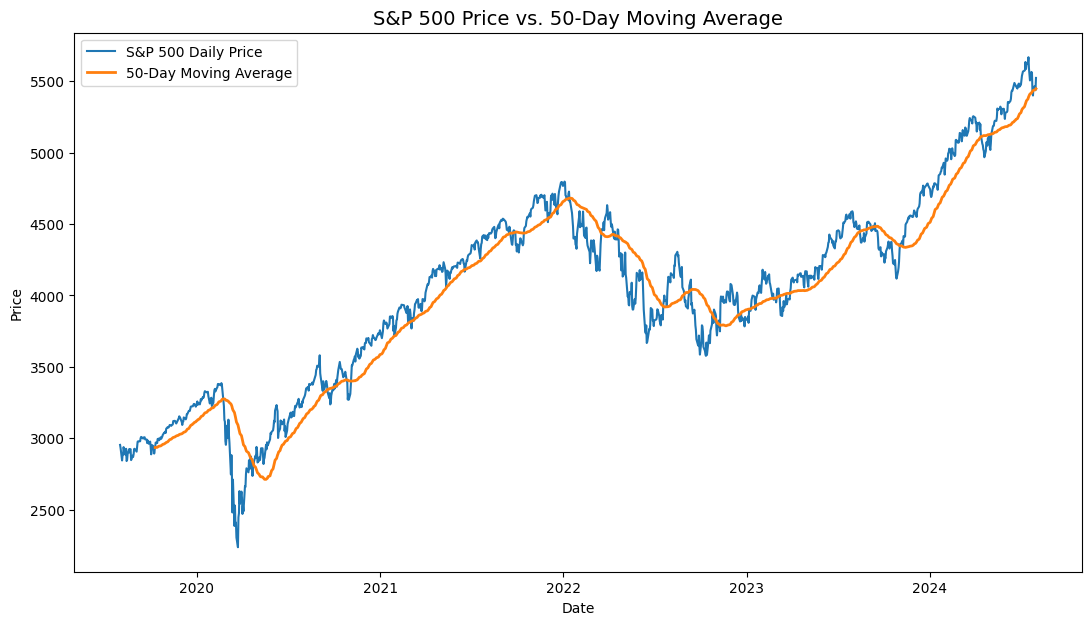

In [40]:
# === 9.2a Visualization: Price vs. 50-Day Moving Average ===

# Create a temporary column in our prices_df to store the 50-day rolling average for the S&P 500.
prices_df['SP500_50_day_avg'] = prices_df['SP500'].rolling(window=50).mean()

# --- Plotting ---
plt.figure(figsize=(13, 7))

# Plot the daily S&P 500 prices.
sns.lineplot(x="Date", y="SP500", data=prices_df, label="S&P 500 Daily Price")

# Plot the 50-day rolling average.
sns.lineplot(x="Date", y="SP500_50_day_avg", data=prices_df, label="50-Day Moving Average", linewidth=2)

plt.title('S&P 500 Price vs. 50-Day Moving Average', fontsize=14)
plt.ylabel('Price')
plt.legend()
plt.show()

This visualization helps to smooth out short-term fluctuations and highlight the longer-term trend. The orange line (moving average) is much smoother than the volatile blue line (daily price).

Now, we can create a volatility metric based on the **distance** between the daily price and this moving average. To ensure positive and negative deviations are treated equally, we'll use the absolute difference. We will also standardize this difference by dividing by the price, giving us a daily percentage deviation. The average of these daily deviations will be our final metric.

**Formula:**
$$ \text{Moving Avg Volatility} = \text{mean}\left( \frac{|\text{Price}_t - \text{MovingAvg}_{50, t}|}{\text{Price}_t} \right) $$

In [41]:
# === 9.2b Volatility Metric 2: Average Rolling Distance ===

# Calculate the 50-day rolling average for both indices.
rolling_avg_50 = prices_df[['SP500', 'Russell2000']].rolling(window=50).mean()

# Calculate the absolute difference between the daily price and the rolling average.
absolute_difference = (prices_df[['SP500', 'Russell2000']] - rolling_avg_50).abs()

# Standardize by dividing by the daily price.
standardized_difference = absolute_difference / prices_df[['SP500', 'Russell2000']]

# Calculate the mean of these daily percentage deviations to get our final metric.
moving_average_volatility = standardized_difference.mean()

print("Volatility based on average distance from 50-day moving average:")
print(moving_average_volatility)

Volatility based on average distance from 50-day moving average:
Ticker
SP500         0.037068
Russell2000   0.048725
dtype: float64


### **5.3 Price Volatility: Standard Deviation of Returns**

The most widely used measure of financial risk is the **standard deviation of returns**. It quantifies the dispersion or "spread" of an asset's returns around its average return. A higher standard deviation implies greater volatility and, therefore, higher risk.

While we could calculate the standard deviation of prices, it's not very useful for comparison because the indices have different price levels. Calculating it on the **daily log returns** provides a standardized, comparable measure.

In [42]:
# === 9.3 Volatility Metric 3: Standard Deviation of Daily Returns ===

# Calculate the standard deviation for the raw prices (for demonstration).
# As noted in the markdown, this is not a useful comparative metric.
price_std = prices_df[['SP500', 'Russell2000']].std()
print("Standard Deviation of Prices (not for comparison):")
print(price_std)
print("-" * 40)


# Calculate the standard deviation of the daily log returns.
# This is the standard industry measure for volatility.
return_std = log_returns_df.std()
print("Standard Deviation of Daily Log Returns (Volatility):")
print(return_std)
print("-" * 40)


# --- Annualized Volatility ---
# To make this number more intuitive, we can annualize it.
# We do this by multiplying the daily volatility by the square root of the number of trading days in a year.
annualized_volatility = return_std * np.sqrt(252)
print("Annualized Volatility:")
print(annualized_volatility.apply(lambda x: f"{x:.2%}"))

Standard Deviation of Prices (not for comparison):
Ticker
SP500         685.682781
Russell2000   284.232353
dtype: float64
----------------------------------------
Standard Deviation of Daily Log Returns (Volatility):
Ticker
SP500         0.013458
Russell2000   0.017503
dtype: float64
----------------------------------------
Annualized Volatility:
Ticker
SP500          21.36%
Russell2000    27.78%
dtype: object


### **5.4 Writing a Volatility Comparison Function in Python**

To make our analysis reproducible and easily applicable to other assets, we will create a function that automates the entire process. This function, `investCompare`, will accept a start date, end date, and a dictionary of tickers as input, and it will return a clean DataFrame summarizing our key metrics.

**Function Parameters:**
-   `startTime`: The beginning of the date range (a `datetime.date` object).
-   `endTime`: The end of the date range (a `datetime.date` object).
-   `tickers`: A dictionary mapping the ticker symbol to a desired display name (e.g., `{"^GSPC": "SP500"}`).

By building a function, we adhere to the DRY (Don't Repeat Yourself) principle of programming.

In [44]:
def investCompare(startTime, endTime, tickers):
    """
    Downloads financial data for a given set of tickers and time period,
    and returns a DataFrame comparing their volatility and returns.

    Args:
        startTime (datetime.date): The start date for data retrieval.
        endTime (datetime.date): The end date for data retrieval.
        tickers (dict): A dictionary mapping ticker symbols to display names.

    Returns:
        pandas.DataFrame: A DataFrame with volatility and return metrics for each asset.
    """
    # === 1. Data Retrieval and Preparation ===
    # Download the adjusted closing prices from Yahoo Finance.
    prices = yfin.download(
        list(tickers.keys()),
        start=startTime,
        end=endTime,
        auto_adjust=False,
        progress=False # Suppress the download progress bar for a cleaner output
    )["Adj Close"]

    # Rename columns for readability.
    prices = prices.rename(columns=tickers)

    # Calculate daily log returns.
    returns = np.log(prices).diff().dropna()


    # === 2. Metric Calculation ===
    # --- Metric 1: Standardized High-Low Range (1-Year) ---
    end_of_period = prices.index.max()
    start_of_last_year = end_of_period - datetime.timedelta(days=365)
    last_year_prices = prices.loc[start_of_last_year : end_of_period]
    high_low_range = (last_year_prices.max() - last_year_prices.min()) / prices.iloc[-1]
    high_low_df = pd.DataFrame(high_low_range, columns=["HighMinusLow"])


    # --- Metric 2: Moving Average Volatility (50-Day) ---
    ma_vol = ((prices - prices.rolling(50).mean()).abs() / prices).mean()
    ma_vol_df = pd.DataFrame(ma_vol, columns=["MovingAverageVolatility"])


    # --- Metric 3: Standard Deviation of Daily Returns ---
    std_dev = returns.std()
    std_dev_df = pd.DataFrame(std_dev, columns=["StandardDeviation"])


    # --- Metric 4: Average Daily Return ---
    avg_return = returns.mean()
    avg_return_df = pd.DataFrame(avg_return, columns=["Daily Return Percentage"])


    # === 3. Combine and Format Results ===
    # Combine all metrics into a single DataFrame.
    # The .join() method can take a list of DataFrames.
    investments = high_low_df.join([ma_vol_df, std_dev_df, avg_return_df])


    # --- Formatting for Display ---
    # Round the High-Low column to 4 decimal places.
    investments["HighMinusLow"] = investments["HighMinusLow"].round(4)

    # Format the other columns as percentages with 3 decimal places.
    percent_cols = ["MovingAverageVolatility", "StandardDeviation", "Daily Return Percentage"]
    for col in percent_cols:
        investments[col] = (investments[col] * 100).apply(lambda x: f"{x:.3f}%")

    return investments

### **5.5 Running and Interpreting the Volatility Function**

Now that we have our `investCompare` function, we can easily run our analysis.

#### **Example 1: S&P 500 vs. Russell 2000**

First, let's re-run our comparison of large-cap vs. small-cap stocks over the last five years. As we've seen throughout this lesson, the results consistently show that the Russell 2000 has been more volatile than the S&P 500. The S&P 500 also provided a higher average daily return during this period.

In [45]:
# === 10.1 Function Application: S&P 500 vs. Russell 2000 ===

# Define the time period and the tickers for our analysis.
start_period_1 = datetime.date(2019, 8, 1)
end_period_1 = datetime.date(2024, 8, 1)
tickers_1 = {"^GSPC": "SP500", "^RUT": "Russell2000"}

# Call our function and display the resulting DataFrame.
sp500_vs_russell = investCompare(start_period_1, end_period_1, tickers_1)
display(sp500_vs_russell)

,HighMinusLow,MovingAverageVolatility,StandardDeviation,Daily Return Percentage
Ticker,,,,
SP500,0.280600,3.707%,1.346%,0.050%
Russell2000,0.278000,4.873%,1.750%,0.030%


#### **Example 2: Adding an Individual Stock (Apple)**

Our function is flexible. Let's add an individual stock, Apple (`AAPL`), to the comparison. The results show that Apple provided a much higher daily return but also came with significantly higher volatility across all three metrics compared to the broad market indices. This is expected, as a single stock is inherently less diversified and therefore riskier than a basket of 500 or 2,000 stocks.

In [46]:
# === 10.2 Function Application: Indices vs. Apple Inc. ===

# Simply add 'AAPL' to our tickers dictionary.
tickers_2 = {"^GSPC": "SP500", "^RUT": "Russell2000", "AAPL": "Apple"}

# Call the function with the updated tickers.
indices_vs_apple = investCompare(start_period_1, end_period_1, tickers_2)
display(indices_vs_apple)

,HighMinusLow,MovingAverageVolatility,StandardDeviation,Daily Return Percentage
Ticker,,,,
Apple,0.315400,6.462%,2.008%,0.118%
SP500,0.280600,3.707%,1.346%,0.050%
Russell2000,0.278000,4.873%,1.750%,0.030%


## **6. Comparing Growth vs. Value Stocks**

We can continue using our function to examine and compare different investment styles.

*   **Growth Stocks (VUG):** Represented by the Vanguard Growth ETF.
*   **Value Stocks (VTV):** Represented by the Vanguard Value ETF.

First, let's look at the last two years.

In [47]:
# === 10.3 Function Application: Growth vs. Value (2-Year) ===

start_period_2 = datetime.date(2022, 8, 1)
end_period_2 = datetime.date(2024, 8, 1)
tickers_3 = {"VUG": "Growth", "VTV": "Value"}

growth_vs_value_2yr = investCompare(start_period_2, end_period_2, tickers_3)
display(growth_vs_value_2yr)

,HighMinusLow,MovingAverageVolatility,StandardDeviation,Daily Return Percentage
Ticker,,,,
Value,0.230600,2.546%,0.825%,0.050%
Growth,0.358200,4.083%,1.284%,0.078%


Over the last two years, growth stocks have clearly outperformed value stocks in terms of returns, but at the cost of higher volatility. Let's see if this trend holds over a much longer timeframe (since 2010).

In [48]:
# === 10.4 Function Application: Growth vs. Value (Long-Term) ===

start_period_3 = datetime.date(2010, 8, 1)
end_period_3 = datetime.date(2024, 8, 1)

growth_vs_value_long = investCompare(start_period_3, end_period_3, tickers_3)
display(growth_vs_value_long)

,HighMinusLow,MovingAverageVolatility,StandardDeviation,Daily Return Percentage
Ticker,,,,
Value,0.230600,2.753%,1.043%,0.045%
Growth,0.358200,3.435%,1.224%,0.059%


## **7. Comparing Domestic vs. Foreign Stocks**

Finally, let's compare the performance and volatility of U.S. stocks against foreign markets.

-   **U.S. Stocks:** Represented by the S&P 500 (`^GSPC`).
-   **Europe Stocks:** Represented by the SPDR Portfolio Europe ETF (`SPEU`).
-   **China Stocks:** Represented by the SPDR S&P China ETF (`GXC`).

We'll start by analyzing the last two years.

In [49]:
# === 10.5 Function Application: Domestic vs. Foreign (2-Year) ===

tickers_4 = {"^GSPC": "SP500", "SPEU": "Europe ETF", "GXC": "China ETF"}

# Use the 2-year period defined previously.
foreign_vs_domestic_2yr = investCompare(start_period_2, end_period_2, tickers_4)

print("--- Analysis for the Last 2 Years ---")
display(foreign_vs_domestic_2yr)

--- Analysis for the Last 2 Years ---


,HighMinusLow,MovingAverageVolatility,StandardDeviation,Daily Return Percentage
Ticker,,,,
China ETF,0.263800,4.816%,1.633%,-0.025%
Europe ETF,0.232400,3.378%,1.051%,0.055%
SP500,0.280600,2.985%,0.980%,0.058%


Over the last two years, the China ETF has been the most volatile and has shown a negative average daily return. The Europe ETF and the S&P 500 show similar returns, with the U.S. market being slightly less volatile.

Now, let's zoom out and look at the data since 2010 to see the longer-term trends.

In [51]:
# === 10.6 Function Application: Domestic vs. Foreign (Long-Term) ===

# Use the long-term period defined previously.
foreign_vs_domestic_long = investCompare(start_period_3, end_period_3, tickers_4)

print("\n--- Analysis Since 2010 ---")
display(foreign_vs_domestic_long)


--- Analysis Since 2010 ---


,HighMinusLow,MovingAverageVolatility,StandardDeviation,Daily Return Percentage
Ticker,,,,
China ETF,0.263800,4.521%,1.567%,0.006%
Europe ETF,0.232400,3.241%,1.233%,0.021%
SP500,0.280600,2.884%,1.085%,0.045%


**Key Takeaways:**

Over the longer period since 2010, the U.S. equities (S&P 500) have provided the highest returns with the lowest volatility of the three. The China ETF, while still showing the highest volatility, now has a positive (though small) average daily return over this longer timeframe.

This again highlights the importance of the chosen timeframe in investment analysis. Short-term performance can be misleading, and long-term trends may present a different picture. A balanced approach, considering both recent performance and long-term history, is crucial for making informed decisions.

## **8. Conclusion**

This lesson served as a comprehensive introduction to fetching, cleaning, and analyzing financial price data using Python. We explored several key concepts:

1.  **Data Retrieval:** We successfully used the `yfinance` library to download historical price data for a variety of assets, including individual stocks (AMZN, F, AAPL), cryptocurrencies (BTC), bonds (BLV), and broad market indices.

2.  **Performance Analysis:** We moved beyond raw price comparisons to calculate meaningful performance metrics like **total simple return** and **annualized geometric return**, correctly accounting for the different trading calendars of various assets.

3.  **Volatility Measurement:** We implemented and compared three distinct volatility metrics: the standardized **high-low range**, the **average distance from a moving average**, and the industry-standard **standard deviation of log returns**.

4.  **Reusable Tools:** By enca

---
### **References**

-   Maginn, John L. *Managing Investment Portfolios Workbook: A Dynamic Process*. John Wiley & Sons, Inc., 2007.

-   Standard & Poor's. *S&P U.S. Indices Methodology*. Nov. 2021, https://www.spglobal.com/spdji/en/documents/methodologies/methodology-sp-us-indices.pdf.

-   Vanguard. "BLV Long-Term Bond ETF." https://institutional.vanguard.com/investments/product-details/fund/0927.

MODULE 2 | LESSON 2
---

# **Financial Asset & Return Analysis**

| | |
|:---|:---|
|**Reading Time** | 60 minutes |
|**Prior Knowledge** | Basic Python |
|**Keywords** | Log and simple returns, Variance, Standard Deviation, Correlation, Covariance, Sharpe Ratio, Semivariance |

---

*This lesson will build upon the previous lessons' focus on price to finally expand the conversation to returns. We go much more in depth into how to calculate returns and how to compare two investments using various risk measures. Then, we take that a step further by using distributions to correctly model risk and returns.*

In [52]:
# === 1. Environment Setup: Import Libraries ===

# Core data handling and numerical operations
import datetime
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Financial data retrieval
import yfinance as yfin

# Statistical analysis
from scipy import stats

# --- Display Options ---
# Set a Pandas display option to format floating-point numbers for better readability.
pd.options.display.float_format = "{:,.6f}".format

print("Libraries imported successfully!")

Libraries imported successfully!


## **1. Obtaining and Transforming Financial Data**

### **1.1 Importing and Understanding the Data**

We will start by pulling price data into Python and transforming it into a format that is easier to work with. For this lesson, we will use the `yfinance` library to pull data for the two most popular U.S. indices, the NASDAQ (`^IXIC`) and S&P 500 (`^GSPC`), along with the daily prices for Bitcoin (`BTC-USD`).

We need to compare **returns** instead of prices for a couple of key reasons:
1.  **Scale-Free:** Returns are a normalized, scale-free summary of an investment opportunity, allowing for an apples-to-apples comparison.
2.  **Statistical Properties:** Returns have more desirable statistical properties for financial modeling, which we will explore in this lesson.

There are two common types of returns:

**Simple Returns Formula**
$$R_{simple} = \frac{P_1 - P_0}{P_0}$$

**Log Returns Formula**
$$R_{log} = \ln\left( \frac{P_1}{P_0} \right) = \ln(P_1) - \ln(P_0)$$

For many financial models that assume returns are normally distributed, log returns are preferred due to their convenient mathematical properties (like being time-additive). We will primarily use log returns in this lesson.

In [53]:
# === 2. Data Retrieval and Preparation ===

# --- Parameters ---
# Define the tickers and their desired column names in a dictionary.
tickers = {
    "^GSPC": "SP500",
    "^IXIC": "NASDAQ",
    "BTC-USD": "Bitcoin"
}

# Define the start and end dates for our data retrieval.
start_date = datetime.date(2019, 8, 1)
end_date = datetime.date(2024, 8, 1)

# --- Data Download ---
# Download the 'Adj Close' data for the specified tickers.
df = yfin.download(
    list(tickers.keys()),
    start=start_date,
    end=end_date,
    auto_adjust=False
)['Adj Close']

# --- Data Cleaning ---
# Rename the columns to be more intuitive using the dictionary.
df = df.rename(columns=tickers)

# --- Initial Data Inspection ---
print("Successfully downloaded and renamed data.")
df.head()

[*********************100%***********************]  3 of 3 completed

Successfully downloaded and renamed data.


Ticker,Bitcoin,SP500,NASDAQ
Date,,,
2019-08-01,"10,399.668945","2,953.560059","8,111.120117"
2019-08-02,"10,518.174805","2,932.050049","8,004.069824"
2019-08-03,"10,821.726562",NaN,NaN
2019-08-04,"10,970.184570",NaN,NaN
2019-08-05,"11,805.653320","2,844.739990","7,726.040039"


### **1.2 Calculating Log Returns and Handling Missing Data**

To prepare our data for analysis, we will perform two key steps:
1.  **Handle Missing Data:** As observed, the S&P 500 and NASDAQ data have `NaN` values on weekends. A common and simple approach for this kind of analysis is to remove these non-trading days entirely. We will use `.dropna()` to remove any row containing at least one `NaN` value.
2.  **Calculate Log Returns:** We will then calculate the daily log returns for the cleaned price data.

In [54]:
# === 3. Data Transformation: Prices to Log Returns ===

# --- Data Cleaning ---
# First, remove rows with any NaN values. This effectively removes the weekend data points
# where the stock indices did not trade, creating a synchronized timeline for all assets.
prices_cleaned = df.dropna()

# --- Return Calculation ---
# Calculate the log returns in a single vectorized operation.
# np.log() is applied to the entire DataFrame.
# .diff() calculates the difference from the previous row (ln(P1) - ln(P0)).
log_returns_df = np.log(prices_cleaned).diff()

# The first row after a .diff() or .pct_change() is always NaN, so we drop it.
log_returns_df = log_returns_df.dropna()


# --- Display the cleaned data ---
print("Cleaned daily log returns:")
log_returns_df.head()

Cleaned daily log returns:


Ticker,Bitcoin,SP500,NASDAQ
Date,,,
2019-08-02,0.011331,-0.007309,-0.013286
2019-08-05,0.115474,-0.030230,-0.035354
2019-08-06,-0.028132,0.012933,0.013784
2019-08-07,0.039612,0.000767,0.003767
2019-08-08,0.002044,0.018588,0.022178


### **1.3 Show Summary Stats for the Returns**

First, let's get a high-level overview of our log returns data using the `.describe()` method.

In [55]:
# === 4.1 Statistical Analysis: Summary of Returns ===

log_returns_df.describe()

Ticker,Bitcoin,SP500,NASDAQ
count,"1,257.000000","1,257.000000","1,257.000000"
mean,0.001453,0.000498,0.000616
std,0.041542,0.013458,0.015952
min,-0.464730,-0.127652,-0.131492
25%,-0.016203,-0.005256,-0.006802
50%,0.000365,0.000866,0.001270
75%,0.020095,0.007240,0.009293
max,0.191527,0.089683,0.089347


## **2. Variance and Standard Deviation**

Volatility is a critical concept for investors. It measures the degree of variation of a trading price series over time, usually quantified by the **variance** or **standard deviation**.

**Variance ($\sigma^2$)** measures the average squared difference of each data point from the mean. A larger variance means the data is more spread out.

$$ \sigma^2 = \frac{\sum(x_i - \bar{x})^2}{n-1} $$

**Standard Deviation ($\sigma$)** is the square root of the variance. It is often preferred because it is in the same unit as the original data (in our case, the daily return), making it more intuitive to interpret.

$$ \sigma = \sqrt{\sigma^2} $$

A higher standard deviation implies greater price swings and higher risk. We would expect a newer, more speculative asset like Bitcoin to have a much higher standard deviation of returns compared to broad stock indices like the S&P 500 and NASDAQ.

In [56]:
# === 4.2 Volatility Calculation: Standard Deviation of Returns ===

# Calculate the standard deviation of the daily log returns for each asset.
daily_volatility = log_returns_df.std()

print("--- Daily Volatility (Standard Deviation of Daily Log Returns) ---")
print(daily_volatility)

# To make the volatility more intuitive, we can annualize it.
# We multiply the daily volatility by the square root of the number of trading days in a year (~252).
trading_days = 252
annualized_volatility = daily_volatility * np.sqrt(trading_days)

print("\n--- Annualized Volatility ---")
print(annualized_volatility.apply(lambda x: f"{x:.2%}"))

--- Daily Volatility (Standard Deviation of Daily Log Returns) ---
Ticker
Bitcoin   0.041542
SP500     0.013458
NASDAQ    0.015952
dtype: float64

--- Annualized Volatility ---
Ticker
Bitcoin    65.95%
SP500      21.36%
NASDAQ     25.32%
dtype: object


The results confirm our expectations: the S&P 500 and NASDAQ have very similar daily volatilities, while Bitcoin's volatility is substantially higher. The annualized numbers show that a one-standard-deviation move for Bitcoin over a year (\~88%) is dramatically larger than for the stock indices (~21-25%).

We can also visualize this difference in volatility by plotting the daily returns. To make a fair comparison, we will set the y-axis limits to be the same for both plots.

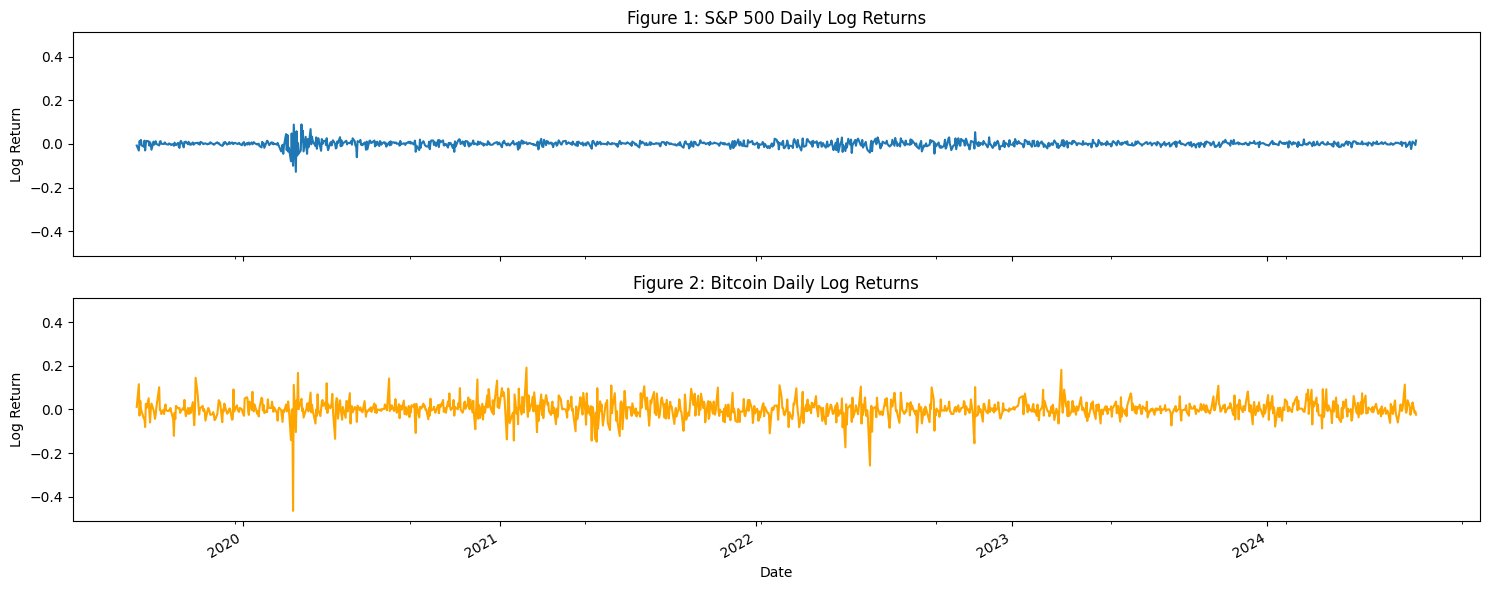

In [57]:
# === 4.3 Visualization: Comparing Return Volatility ===

# Create a figure with two subplots side-by-side to compare volatility.
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(15, 6), sharex=True, sharey=True)

# Plot S&P 500 daily returns on the first subplot.
log_returns_df['SP500'].plot(ax=ax1, title="Figure 1: S&P 500 Daily Log Returns")
ax1.set_ylabel("Log Return")

# Plot Bitcoin daily returns on the second subplot.
log_returns_df['Bitcoin'].plot(ax=ax2, title="Figure 2: Bitcoin Daily Log Returns", color='orange')
ax2.set_ylabel("Log Return")

# Set shared y-axis limits for a fair visual comparison.
# We'll set the limits based on the most volatile asset (Bitcoin) to ensure all data is visible.
y_limit = (log_returns_df['Bitcoin'].abs().max() * 1.1) # Find max absolute value and add 10% padding
plt.ylim(-y_limit, y_limit)


plt.xlabel("Date")
plt.tight_layout() # Adjust layout to prevent titles/labels from overlapping
plt.show()

## **3. Covariance and Correlation**

Understanding how assets perform individually is important, but for building a portfolio, it's crucial to understand how they perform **together**. Covariance and correlation are the key statistical measures for this.

**Covariance** measures the joint variability of two random variables.

$$ \text{cov}(X,Y) = \frac{\sum(x_{i}-\bar{x})(y_{i}-\bar{y})}{N-1} $$

-   A **positive covariance** means that the assets' returns tend to move in the same direction.
-   A **negative covariance** means they tend to move in opposite directions.

While covariance gives us the direction of the relationship, its magnitude is hard to interpret because it's not standardized. The values below are all positive, indicating that on days the S&P 500 goes up, NASDAQ and Bitcoin also *tend* to go up.

In [58]:
# === 5.1 Relationship Analysis: Covariance Matrix ===

# Calculate the covariance matrix of the daily log returns.
log_returns_df.cov()

Ticker,Bitcoin,SP500,NASDAQ
Ticker,,,
Bitcoin,0.001726,0.000200,0.000253
SP500,0.000200,0.000181,0.000203
NASDAQ,0.000253,0.000203,0.000254


### **3.1 The Pearson Correlation Coefficient**

**Correlation** is a much more intuitive measure because it standardizes covariance. The result is a value between -1 and +1 that tells us not only the direction but also the **strength** of the linear relationship between two variables.

$$ \rho_{X,Y} = \frac{\text{cov}(X,Y)}{\sigma_{X} \sigma_{Y}} $$

-   **+1**: Perfect positive correlation. The assets move perfectly in sync.
-   **-1**: Perfect negative correlation. The assets move in perfectly opposite directions.
-   **0**: No linear correlation. The assets' movements are unrelated.

A key benefit of correlation is this standardized scale, which makes it easy to compare relationships across different pairs of assets.

In [59]:
# === 5.2 Relationship Analysis: Correlation Matrix ===

# Calculate the Pearson correlation matrix of the daily log returns.
# We round the result to 3 decimal places for easier reading.
correlation_matrix = log_returns_df.corr()

print("--- Correlation Matrix of Daily Log Returns ---")
display(round(correlation_matrix, 3))

--- Correlation Matrix of Daily Log Returns ---


Ticker,Bitcoin,SP500,NASDAQ
Ticker,,,
Bitcoin,1.000000,0.358000,0.381000
SP500,0.358000,1.000000,0.947000
NASDAQ,0.381000,0.947000,1.000000


### **3.2 Visualizing the Correlations**

The correlation matrix gives us the numbers, but a chart can provide a more intuitive understanding. We'll use scatter plots with regression lines (`regplot` in seaborn) to visualize these relationships.

First, let's plot the S&P 500 vs. the NASDAQ. We expect to see a tight, upward-sloping cloud of points, confirming their strong positive correlation.

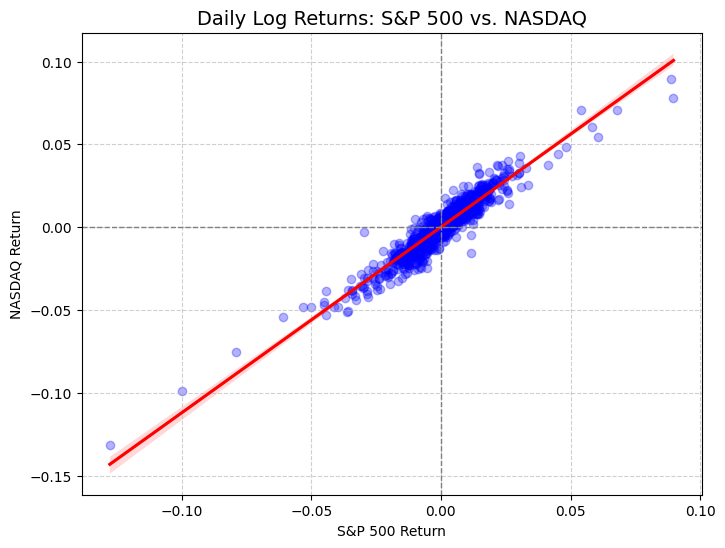

In [60]:
# === 5.3 Visualization: S&P 500 vs. NASDAQ Correlation ===

plt.figure(figsize=(8, 6))

# Create a scatter plot with a linear regression line.
sns.regplot(x="SP500", y="NASDAQ", data=log_returns_df,
            scatter_kws={'alpha':0.3, 'color': 'blue'}, # Make points semi-transparent
            line_kws={'color': 'red'})                 # Make the regression line red

# Add reference lines at x=0 and y=0 to represent the quadrants.
plt.axhline(0, linestyle="--", color="grey", linewidth=1)
plt.axvline(0, linestyle="--", color="grey", linewidth=1)

plt.title("Daily Log Returns: S&P 500 vs. NASDAQ", fontsize=14)
plt.xlabel("S&P 500 Return")
plt.ylabel("NASDAQ Return")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

As expected, the plot shows a strong linear relationship. Most points are clustered in the top-right (both positive) and bottom-left (both negative) quadrants, which is characteristic of a high positive correlation (~0.943).

Now, let's visualize the relationship between the S&P 500 and Bitcoin. Based on the correlation of ~0.205, we expect a much more scattered plot with a slight upward trend.

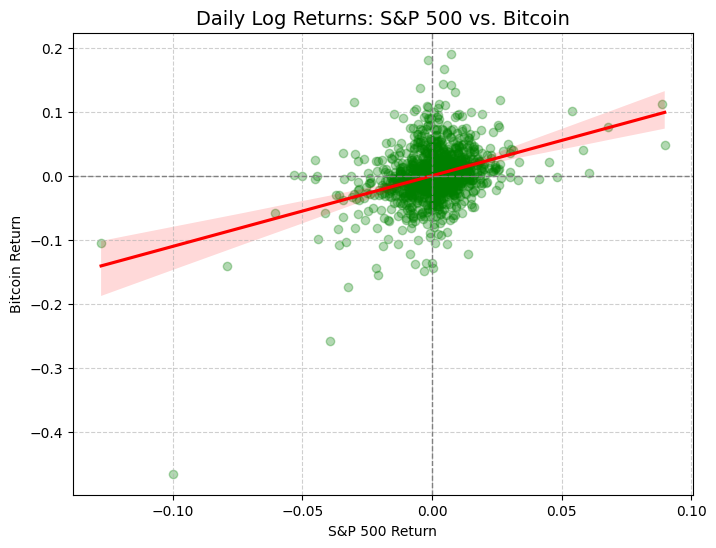

In [61]:
# === 5.4 Visualization: S&P 500 vs. Bitcoin Correlation ===

plt.figure(figsize=(8, 6))

# Create the scatter plot for SP500 vs. Bitcoin.
sns.regplot(x="SP500", y="Bitcoin", data=log_returns_df,
            scatter_kws={'alpha':0.3, 'color': 'green'},
            line_kws={'color': 'red'})

# Add reference lines.
plt.axhline(0, linestyle="--", color="grey", linewidth=1)
plt.axvline(0, linestyle="--", color="grey", linewidth=1)

plt.title("Daily Log Returns: S&P 500 vs. Bitcoin", fontsize=14)
plt.xlabel("S&P 500 Return")
plt.ylabel("Bitcoin Return")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### **3.3 The Sharpe Ratio**

While correlation tells us how assets move together, the **Sharpe Ratio** helps us evaluate an individual asset's performance by relating its return to its volatility. It is the most common measure of **risk-adjusted return**.

The formula is:
$$ \text{Sharpe Ratio} = \frac{R_p - R_f}{\sigma_p} $$

Where:
-   $R_p$ = The average return of the portfolio/asset.
-   $R_f$ = The risk-free rate (the return of an investment with zero risk, like a U.S. Treasury bill).
-   $\sigma_p$ = The standard deviation of the portfolio/asset's excess return.

A higher Sharpe Ratio is better, as it indicates a higher return per unit of risk.

For simplicity in many analyses, especially when dealing with short time periods like daily returns, the risk-free rate ($R_f$) is often assumed to be 0. The formula then simplifies to:

$$ \text{Sharpe Ratio} \approx \frac{R_p}{\sigma_p} $$

We will use this simplified version to compare the S&P 500 and Bitcoin.

In [62]:
# === 5.5 Risk-Adjusted Return: Sharpe Ratio ===

# Calculate the mean daily log return for each asset.
mean_returns = log_returns_df.mean()

# Calculate the daily volatility (standard deviation) for each asset.
volatility = log_returns_df.std()

# Calculate the simplified Sharpe Ratio (assuming risk-free rate is 0).
sharpe_ratio = mean_returns / volatility

print("--- Daily Sharpe Ratios (Risk-Free Rate = 0) ---")
print(sharpe_ratio)

# --- Annualized Sharpe Ratio ---
# To make the Sharpe Ratio more comparable across different time frames, it is often annualized.
# We do this by multiplying the daily Sharpe Ratio by the square root of the number of trading days.
annualized_sharpe_ratio = sharpe_ratio * np.sqrt(252) # Using 252 for all for direct comparison

print("\n--- Annualized Sharpe Ratios ---")
print(annualized_sharpe_ratio)

--- Daily Sharpe Ratios (Risk-Free Rate = 0) ---
Ticker
Bitcoin   0.034982
SP500     0.036991
NASDAQ    0.038631
dtype: float64

--- Annualized Sharpe Ratios ---
Ticker
Bitcoin   0.555328
SP500     0.587215
NASDAQ    0.613245
dtype: float64


Based on the annualized results, the S&P 500 has a Sharpe Ratio of approximately **0.59**, while Bitcoin's is slightly lower at **0.55**. This suggests that over this period, after accounting for its significantly higher volatility, the S&P 500 offered a slightly better risk-adjusted return than Bitcoin.

**Important Note:** A major limitation of the standard Sharpe Ratio is its use of standard deviation, which implicitly assumes that returns are normally distributed and treats upside volatility (good) and downside volatility (bad) equally.

## **4. Semivariance: A Focus on Downside Risk**

A major flaw with standard deviation (and thus the Sharpe Ratio) is that it treats all volatility the same. It penalizes an investment for large positive returns just as much as it does for large negative returns.

Most long-term investors are primarily concerned with **downside risk**. **Semivariance** is a risk measure that addresses this by only considering the returns that fall *below* the average return. It calculates the average squared deviation of these "underperforming" returns.

$$ \text{Semivariance} = \frac{1}{n} \sum_{r_i < \bar{r}}^{n} (r_i - \bar{r})^2 $$

Where the sum is only taken for returns ($r_i$) that are less than the mean return ($\bar{r}$).

A higher semivariance indicates greater downside risk, meaning the asset has a history of larger or more frequent negative deviations from its average performance.

In [64]:
# === 6.1 Downside Risk: Semivariance Calculation ===

# Calculate the mean return for each asset.
mean_returns = log_returns_df.mean()

# --- Semivariance for S&P 500 ---
# 1. Filter for returns below the mean.
sp500_negative_returns = log_returns_df[log_returns_df['SP500'] < mean_returns['SP500']]
# 2. Calculate the squared differences from the mean for these returns.
sp500_squared_diffs = (sp500_negative_returns['SP500'] - mean_returns['SP500'])**2
# 3. Calculate the mean of these squared differences (the semivariance).
sp500_semivariance = sp500_squared_diffs.mean()


# --- Semivariance for NASDAQ ---
nasdaq_negative_returns = log_returns_df[log_returns_df['NASDAQ'] < mean_returns['NASDAQ']]
nasdaq_squared_diffs = (nasdaq_negative_returns['NASDAQ'] - mean_returns['NASDAQ'])**2
nasdaq_semivariance = nasdaq_squared_diffs.mean()


# --- Semivariance for Bitcoin ---
btc_negative_returns = log_returns_df[log_returns_df['Bitcoin'] < mean_returns['Bitcoin']]
btc_squared_diffs = (btc_negative_returns['Bitcoin'] - mean_returns['Bitcoin'])**2
btc_semivariance = btc_squared_diffs.mean()


# --- Print the results ---
print(f"Semivariance of S&P 500: {sp500_semivariance:.6f}")
print(f"Semivariance of NASDAQ: {nasdaq_semivariance:.6f}")
print(f"Semivariance of Bitcoin: {btc_semivariance:.6f}")

Semivariance of S&P 500: 0.000210
Semivariance of NASDAQ: 0.000298
Semivariance of Bitcoin: 0.001814


In [67]:
# === 6.2 Semivariance Calculation (Corrected Vectorized Method) ===

# This is the correct and concise way to calculate semivariance for all columns.

# 1. Use the .where() method. It keeps values where the condition is True
#    and replaces them with NaN where the condition is False.
negative_returns_only = log_returns_df.where(log_returns_df < mean_returns)

# 2. Square the difference. The operation is still vectorized.
#    Pandas will correctly subtract the mean from the non-NaN values and ignore the NaNs.
squared_diffs = (negative_returns_only - mean_returns)**2

# 3. Calculate the mean. The .mean() function automatically ignores NaN values by default.
semivariance_vectorized = squared_diffs.mean()

print("--- Semivariance (Corrected Vectorized Calculation) ---")
print(semivariance_vectorized)

--- Semivariance (Corrected Vectorized Calculation) ---
Ticker
Bitcoin   0.001814
SP500     0.000210
NASDAQ    0.000298
dtype: float64


The output shows that Bitcoin has a much higher semivariance (\~0.000579) compared to the S&P 500 (\~0.000074) and NASDAQ (\~0.000099). This confirms that Bitcoin not only has higher overall volatility but specifically has a much greater tendency for large negative price swings compared to the stock indices. This is a critical insight for risk management.

## **5. How Are Stock Returns Distributed?**

Many financial models and theories (like the Sharpe Ratio) are built on the assumption that asset returns follow a **normal distribution** (also known as a Gaussian distribution or "bell curve").

Properties of a perfect normal distribution include:
-   **Symmetry:** The mean, median, and mode are all identical. The distribution is perfectly symmetrical around the mean.
-   **Predictable Spread:** ~68% of data falls within +/- 1 standard deviation of the mean, ~95% within +/- 2, and ~99.7% within +/- 3.

If our data is truly normal, we can confidently use mean and standard deviation to model risk and return. If not, these metrics can be misleading, and we may need to consider alternative distributions.

Let's investigate this by pulling 20 years of daily S&P 500 data and calculating its log returns.

In [68]:
# === 7.1 Distribution Analysis: Data Retrieval (20 Years) ===

# --- Parameters ---
start_date_long = datetime.date(2004, 8, 1)
end_date_long = datetime.date(2024, 8, 1)
ticker_long = {"^GSPC": "SP500"}

# --- Data Download and Processing ---
# Download the 'Adj Close' data.
prices_long_df = yfin.download(
    list(ticker_long.keys()),
    start=start_date_long,
    end=end_date_long,
    auto_adjust=False,
    progress=False
)['Adj Close']

# Rename the column.
prices_long_df = prices_long_df.rename(columns=ticker_long)

# Calculate log returns.
log_returns_long_df = np.log(prices_long_df).diff().dropna()

# --- Display Info ---
print(f"Downloaded {len(log_returns_long_df)} daily log returns for the S&P 500.")
log_returns_long_df.head()

Downloaded 5033 daily log returns for the S&P 500.


Ticker,SP500
Date,
2004-08-03,-0.006282
2004-08-04,-0.000964
2004-08-05,-0.016455
2004-08-06,-0.015602
2004-08-09,0.001174


The result is approximately 52.6%, which is close to 50% but not exact. This indicates a slight **negative skew** (the tail on the left side is longer or fatter than the right side), but it's not extreme enough on its own to definitively rule out normality based on this simple test alone.